In [618]:
import pandas as pd
import seaborn as sns
import numpy as np
from numpy import gradient
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import r2_score
from scipy.ndimage.filters import gaussian_filter1d
import math
from scipy import stats
from pygam import LinearGAM, s

def calc_derivatives(x,y):
    """ Calculate the derivative of the fitted function"""
    """
    x: list of points
    y: list of points
    """
    dx = np.diff(x)
    dy = np.diff(y)
    derivative = dy / dx
    return derivative

warnings.filterwarnings( 'ignore' )

pd.options.display.max_columns = None
pd.options.display.max_rows = None

species_color = {'Marmoset': "orange",'Human': "green",'Rhesus': "blue",'Chimpanzee': "red", 'Capuchin': "brown","Gorilla": "pink"}


#PYTHON_PATH = "/Users/rb4174/Documents/projects/brain_dev_primates/altricial_brain_vocal_learning"
PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"


In [619]:
def evaluate_distances_from_peak(x_values,each_derivative,gestation_avg,gestation_sd):
    """ Create a table with important values"""
    possible_values_for_rate_at_birth = []
    max_derivative = np.max(each_derivative)
    for x,y in zip(x_values,each_derivative):
        if x > gestation_avg - gestation_sd and x < gestation_avg + gestation_sd:
            possible_values_for_rate_at_birth.append((max_derivative-y)/max_derivative)

    return possible_values_for_rate_at_birth
    

def create_derivatives_dataset(sensitivity_df,x_each_species,species_list,gestation_periods_plot,gestation_periods_sd):
    derivatives_dataset = {"Species":[],
        "derivatives":[],
        "derivatives_wiggliness":[],
        "derivatives_max":[],
        "derivatives_peak_at_birth":[],
        "growth_curve_r2_score":[],
        "growth_curve_wiggliness":[]}
    
    sensitivity_df["derivative_wiggliness"] = [None]*len(sensitivity_df)
    for species in species_list:
        sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)]
        all_derivatives = []
        all_derivatives_wiggliness = []
        all_derivatives_max = []
        all_derivatives_peak_at_birth = []
        x_values = x_each_species[species]
        r2_original_fit = []
        wiggliness_original_fit = []
        for index, row in sensitivity_df_species.iterrows():
            y_values = row["values"]

            #each_derivative = calc_derivatives(x_values,y_values)
            each_derivative = gradient(y_values, x_values)
            each_derivative_wiggliness = np.sum(gradient(gradient(each_derivative, x_values), x_values)**2)
            each_derivative_max = np.max(each_derivative)
            each_derivative_dist_possible_distance_from_peak_at_birth = evaluate_distances_from_peak(x_values,each_derivative,gestation_periods_plot[species],gestation_periods_sd[species])

            all_derivatives.append(each_derivative)
            all_derivatives_wiggliness.append(each_derivative_wiggliness)
            all_derivatives_max.append(each_derivative_max)
            all_derivatives_peak_at_birth.append(each_derivative_dist_possible_distance_from_peak_at_birth)
            r2_original_fit.append(row["r2_score"])
            wiggliness_original_fit.append(row["wiggliness"])  

            sensitivity_df.loc[index,"derivative_wiggliness"] = each_derivative_wiggliness          


        derivatives_dataset["Species"].append(species)
        derivatives_dataset["derivatives"].append(all_derivatives)
        derivatives_dataset["derivatives_wiggliness"].append(all_derivatives_wiggliness)
        derivatives_dataset["derivatives_max"].append(all_derivatives_max)
        derivatives_dataset["derivatives_peak_at_birth"].append(all_derivatives_peak_at_birth)
        derivatives_dataset["growth_curve_r2_score"].append(r2_original_fit)
        derivatives_dataset["growth_curve_wiggliness"].append(wiggliness_original_fit)

    derivatives_dataset = pd.DataFrame(derivatives_dataset)
    derivatives_dataset.head()

    return derivatives_dataset, sensitivity_df
    

# Opening and preparing datasets

In [620]:
df = pd.read_excel("{0}/data/brain_growth_complete.xlsx".format(PYTHON_PATH),index_col=False)

df.loc[len(df.index) + 1] = [0,0,'Human',"Contour condition",0,0,0]
df.loc[len(df.index) + 1] = [0,0,'Chimpanzee',"Contour condition",0,0,0] 
df.loc[len(df.index) + 1] = [0,0,'Rhesus',"Contour condition",0,0,0] 
df.loc[len(df.index) + 1] = [0,0,'Marmoset',"Contour condition",0,0,0]

df.head()

,age_years,total_cm3,Species,data_origin,days_post_conception,Adult_percent_brain_volume_cm3,weeks_post_conception
0,0.1,394.0,Human,Sakai_2013,306.6,0.309751,43.800000
1,0.3,530.2,Human,Sakai_2013,379.8,0.416828,54.257143
2,0.3,622.5,Human,Sakai_2013,379.8,0.489391,54.257143
3,0.5,652.0,Human,Sakai_2013,453.0,0.512583,64.714286
4,0.7,788.1,Human,Sakai_2013,526.2,0.619581,75.171429


# Create events dicts

In [621]:
df_events = pd.read_excel("{0}/data/developmental_stages_events.xlsx".format(PYTHON_PATH))
df_events = df_events.dropna()
print(df_events["event"].unique())
df_events.head()

['dental_early_infancy_ends' 'dental_late_infancy_ends' 'gestation'
 'sexual_maturation_juvenile_end' 'weaning_complete']


,event_type,event,species,min_wkspc,max_wkspc,avg_wkspc,avg_month_pc,sd_(days),original_format,original_description,data_reference
0,developmental_stages,dental_early_infancy_ends,Chimpanzee,131.654286,131.654286,131.654286,32.913571,0.0,"53.8 weeks, 12 months",ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
1,developmental_stages,dental_early_infancy_ends,Human,320.228571,320.228571,320.228571,80.057143,0.0,"108 weeks, 24 months",ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
2,developmental_stages,dental_early_infancy_ends,Marmoset,37.542857,37.542857,37.542857,9.385714,0.0,5 weeks,ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
3,developmental_stages,dental_early_infancy_ends,Rhesus,61.120629,61.120629,61.120629,15.280157,0.0,0.437 year,ealy infancy = deciduous teeth last eruption,"Smith 1994, Ages of Eruption of Primate Teeth:..."
4,developmental_stages,dental_early_infancy_ends,Capuchin,40.993086,40.993086,40.993086,10.248271,0.0,0.393 year,ealy infancy = deciduous teeth last eruption,"Smith 1994, Ages of Eruption of Primate Teeth:..."


In [622]:
gestation_periods,gestation_periods_sd,late_infancy_ends,early_infancy_ends,juvenile_ends = {},{},{},{},{}

for species in df_events["species"].unique():
    df_events_species= df_events[(df_events.species == species)]
    gestation_periods[species] = df_events_species[(df_events_species.event == "gestation")]["avg_wkspc"].values[0]*7
    gestation_periods_sd[species] = df_events_species[(df_events_species.event == "gestation")]["sd_(days)"].values[0]
    early_infancy_ends[species] = df_events_species[(df_events_species.event == "dental_early_infancy_ends")]["avg_wkspc"].values[0]*7
    late_infancy_ends[species] = df_events_species[(df_events_species.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7
    juvenile_ends[species] = df_events_species[(df_events_species.event == "sexual_maturation_juvenile_end")]["avg_wkspc"].values[0]*7

    
cut_period = {'Chimpanzee': 150, #'late_infancy': 235
 'Human': 300, #'late_infancy': 526
 'Marmoset': 60, #'late_infancy': 48
 'Rhesus': 100, #'late_infancy': 108
    'Capuchin': 100, #'late_infancy': 80
    'Gorilla': 200, #'late_infancy': 217

 }

# Sensitivity analysis

In [623]:
gestation_periods_plot, early_infancy_ends_plot, late_infancy_ends_plot = gestation_periods, early_infancy_ends, late_infancy_ends
FIT_VARIABLE = "days_post_conception" 

species_list = ["Human","Marmoset","Chimpanzee","Rhesus"]#,"Capuchin","Gorilla"]


In [625]:
sensitivity_df = {"Species":[],"values":[],"r2_score":[],"wiggliness":[],
                  "spline_parameter":[],"smooth_parameter":[]}
x_each_species= {}

for species in species_list:
    
    df_species_original = df[(df.Species == species)&(df.days_post_conception < cut_period[species]*7)].sort_values(FIT_VARIABLE) # cut_period,late_infancy_ends
    df_species_original = df_species_original.groupby(FIT_VARIABLE, as_index=False).agg({'Species': 'first', 'data_origin': 'first', 'total_cm3':"mean"})

    #original data points
    x_all_data = list(df_species_original[FIT_VARIABLE])
    y_all_data = list(df_species_original["total_cm3"])

    x_for_prediction = np.arange(0,x_all_data[-1],1)
    x_each_species[species] = x_for_prediction

    print(species)
    for iteration in range(1000):#500
        sample_indices = np.sort(np.random.choice(len(x_all_data), size=len(x_all_data), replace=True))
        x_sample = [x_all_data[i] for i in sample_indices]
        y_sample = [y_all_data[i] for i in sample_indices] 
        x_sample.append(x_all_data[0])
        y_sample.append(y_all_data[0])
        if species == "Chimpanzee":
            #To ensure chimpanzee bootstrap will not be too far from the original data, I am fixing four values that are in a important region of the curve
            for fix_xvalue in [294.24,312.54,352.80,385.74]:
                index_to_fix = x_all_data.index(fix_xvalue)
                x_sample.append(x_all_data[index_to_fix])
                y_sample.append(y_all_data[index_to_fix])

        for smooth_parameter in [0.01,0.05,0.1]: ## smooth_parameter: higher = more smooth (less flexible)
            for n_splines in [20,22,25]:  # n_splines: #higher = more flexible 
                gam = LinearGAM(s(0, constraints='monotonic_inc'), n_splines = n_splines, lam=smooth_parameter, max_iter=100).fit(x_sample, y_sample)
                fitted_function = gam.predict

                # Evaluate the fitted function at x_all_data.
                y_pred_all = fitted_function(x_all_data)
                # Check for NaNs: if found, skip this iteration.
                if np.isnan(y_pred_all).any():
                    continue

                # Evaluate at xi for later use.
                y_pred_xi = fitted_function(x_for_prediction)
                if np.isnan(y_pred_xi).any():
                    continue

                r2 = r2_score(y_all_data, y_pred_all)
                y = fitted_function(x_for_prediction)

                sensitivity_df["r2_score"].append(r2)
                sensitivity_df["wiggliness"].append(np.sum(gradient(gradient(y, x_for_prediction), x_for_prediction)**2))

                sensitivity_df["Species"].append(species)
                sensitivity_df["values"].append(y)

                sensitivity_df["spline_parameter"].append(n_splines)
                sensitivity_df["smooth_parameter"].append(smooth_parameter)
                #sensitivity_df["x_values"].append(x_each_species[species])

            del(fitted_function)
            
sensitivity_df = pd.DataFrame(sensitivity_df)
sensitivity_df = sensitivity_df[sensitivity_df.r2_score > 0.9]
sensitivity_df.head()

Human
did not converge
did not converge
did not converge
Marmoset
Chimpanzee
Rhesus
did not converge


,Species,values,r2_score,wiggliness,spline_parameter,smooth_parameter
0,Human,"[-13.15568653685375, -13.155655890704566, -13....",0.955958,0.073803,20,0.01
1,Human,"[-17.823035956241483, -17.82300183730581, -17....",0.955643,0.070829,22,0.01
2,Human,"[-8.900938656722474, -8.900908841372939, -8.90...",0.955292,0.147737,25,0.01
3,Human,"[-11.238624516784512, -11.238594400523198, -11...",0.955865,0.070264,20,0.05
4,Human,"[-16.111915011792917, -16.111881533329438, -16...",0.955665,0.066807,22,0.05


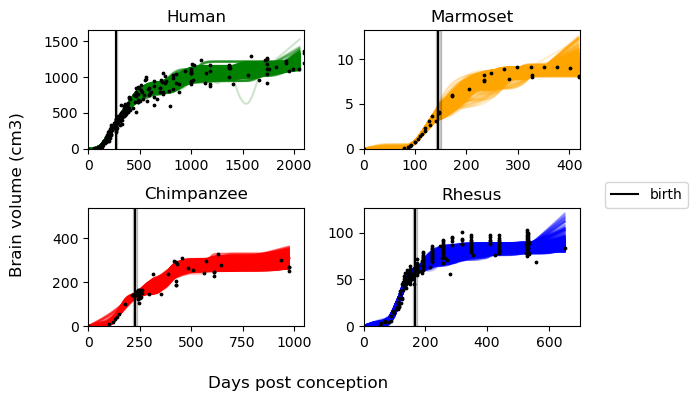

In [626]:
i = 0
fig, ax = plt.subplots(figsize = (6,4),nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        df_species = df[(df.Species == species)]
        sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)]
        col.set_title(species)
        x_values = x_each_species[species]
        for index, row in sensitivity_df_species.iterrows():
            col.plot(x_values, row["values"], '-', color = species_color[species],alpha = 0.2,zorder = 0)
        col.scatter(df_species[FIT_VARIABLE],df_species["total_cm3"],color = "black", marker = 'o', s =3)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')

        col.set_xlim(0,cut_period[species]*7)
        col.set_ylim(bottom=0)
        i += 1


fig.supxlabel('Days post conception') 
fig.supylabel('Brain volume (cm3)')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
#fig.savefig("{0}/figs/S1.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

Human
Marmoset
Chimpanzee
Rhesus


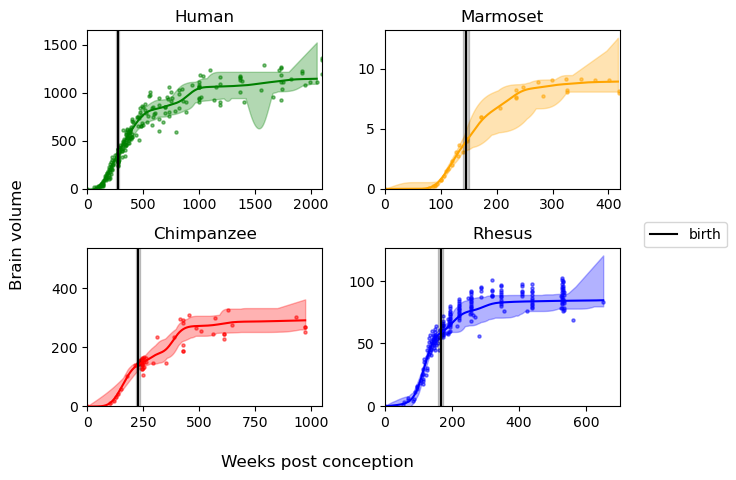

In [627]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        df_species = df[(df.Species == species)]
        sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)]
        col.scatter(df_species[FIT_VARIABLE],df_species["total_cm3"],color = species_color[species], marker = 'o', s =5,alpha =0.5)
        col.set_title(species)
        
        all_curves = sensitivity_df_species["values"].tolist()
        average_curve = np.mean(np.array(all_curves), axis=0)
        min_curve = np.min(np.array(all_curves), axis=0)
        max_curve = np.max(np.array(all_curves), axis=0)


        col.plot(x_each_species[species], average_curve, '-', color = species_color[species],alpha = 1)
        col.fill_between(x_each_species[species], min_curve,max_curve, color=species_color[species], alpha=0.3)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')

        col.set_xlim(0,cut_period[species]*7)
        col.set_ylim(bottom=0)

        i += 1


fig.supxlabel('Weeks post conception') 
fig.supylabel('Brain volume')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#fig.savefig("{0}/figs/S3.pdf".format(PYTHON_PATH),dpi = 300)
plt.tight_layout()
plt.show()

### Calculate and plot derivatives

In [628]:
derivatives_dataset, sensitivity_df = create_derivatives_dataset(sensitivity_df,x_each_species,species_list,gestation_periods_plot,gestation_periods_sd)
derivatives_dataset.head()

,Species,derivatives,derivatives_wiggliness,derivatives_max,derivatives_peak_at_birth,growth_curve_r2_score,growth_curve_wiggliness
0,Human,"[[3.064614918457664e-05, 0.0001225853041546543...","[2.227404646878772e-05, 2.135683822570055e-05,...","[2.4194334486632556, 2.3492183323747895, 2.680...","[[0.06434829108500505, 0.06608864961643122, 0....","[0.9559578868566582, 0.95564256202385, 0.95529...","[0.07380311658005818, 0.07082885638031204, 0.1..."
1,Marmoset,"[[-2.1938006966593093e-13, -2.2071233729548112...","[1.7856470496622017e-06, 3.1977613671746237e-0...","[0.07797830003594997, 0.08633378969969008, 0.0...","[[0.13026423779011284, 0.13111629317214585, 0....","[0.9855174757442907, 0.9862192814290527, 0.986...","[0.0003146313343180215, 0.0003743326140261723,..."
2,Chimpanzee,"[[-1.5944578990456648e-11, -1.6086687537608668...","[0.0001355843181055939, 0.0002496754262742571,...","[1.3923654850155174, 1.4348177313156114, 1.574...","[[0.4782822958437926, 0.47619615921624214, 0.4...","[0.9277530235018379, 0.9339409645824178, 0.933...","[0.06507058595826276, 0.09521936768577788, 0.1..."
3,Rhesus,"[[3.0494334978925508e-05, 0.000121977361324354...","[0.0003030212103977669, 0.00025514043262771973...","[1.0337675876067483, 0.9014116884243286, 1.050...","[[0.7270753007924873, 0.7246512462666181, 0.72...","[0.9329144571410887, 0.9323252682964207, 0.933...","[0.04796197193522571, 0.04183159473648357, 0.0..."


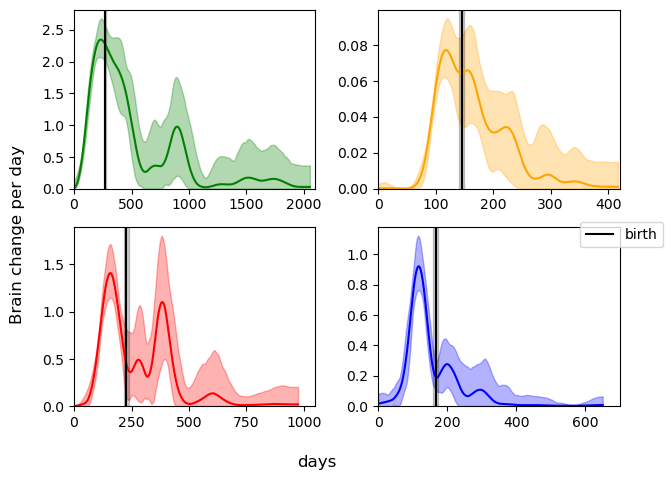

In [629]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species= species_list[i]
        derivatives_dataset_species = derivatives_dataset[(derivatives_dataset.Species == species)]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = np.mean(np.array(all_devs), axis=0)
        low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
        max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

        col.fill_between(x_each_species[species], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)

        col.plot(x_each_species[species], average_derivative, '-', color = species_color[species],alpha = 1)
        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species]*7)

        i += 1

fig.supxlabel('days') 
fig.supylabel('Brain change per day')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.tight_layout()
plt.show()

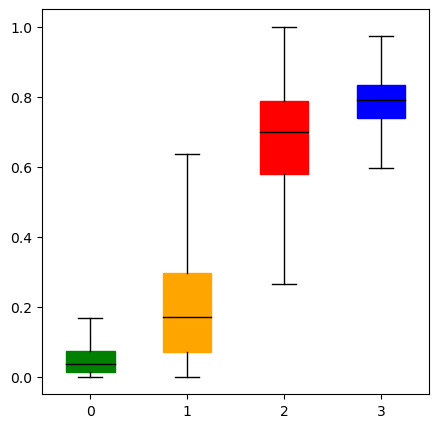

In [630]:
fig, ax = plt.subplots(figsize = (5,5))
for species in species_list:
    derivatives_dataset_species = derivatives_dataset[(derivatives_dataset.Species == species)]
    all_distances_from_the_peak = []
    for each_derivative in derivatives_dataset_species["derivatives_peak_at_birth"].values[0]:
        all_distances_from_the_peak.extend(each_derivative)

    #plot as boxplots, each species in a different position in the x axis:
    ax.boxplot(x = all_distances_from_the_peak, positions= [species_list.index(species)], widths=0.5, showfliers=False,patch_artist=True, boxprops=dict(facecolor=species_color[species], color=species_color[species]), medianprops=dict(color="black"),whiskerprops=dict(color="black"))


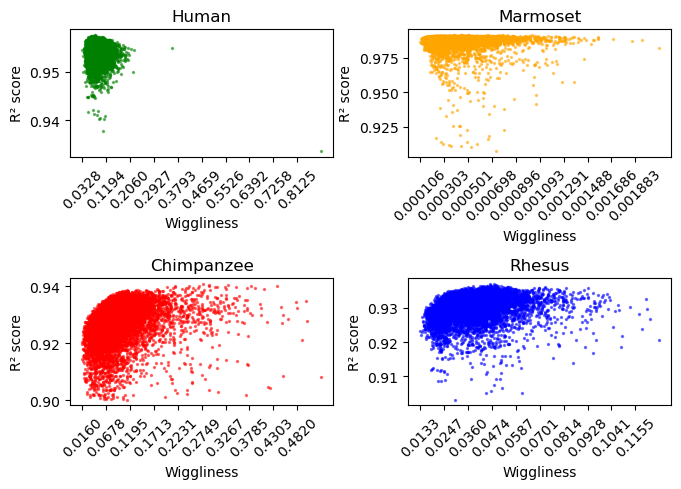

In [631]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(7,5))
i = 0
for row in ax:
    for col in row:
        species = species_list[i]
        sensitivity_df_species = sensitivity_df[sensitivity_df["Species"] == species]

        col.scatter(sensitivity_df_species["wiggliness"],
                    sensitivity_df_species["r2_score"],
                    color=species_color[species],
                    s=2, alpha=0.5)
        col.set_title(species)
        col.set_xlabel("Wiggliness")
        
        x_min_value = np.min(sensitivity_df_species["wiggliness"])
        x_max_value = np.max(sensitivity_df_species["wiggliness"])

        col.set_xticks(np.arange(x_min_value,x_max_value,(x_max_value - x_min_value)/10))
        col.tick_params(axis='x', labelsize=10,rotation=45)
        col.set_ylabel("R² score")
        i += 1
plt.tight_layout()
plt.show()

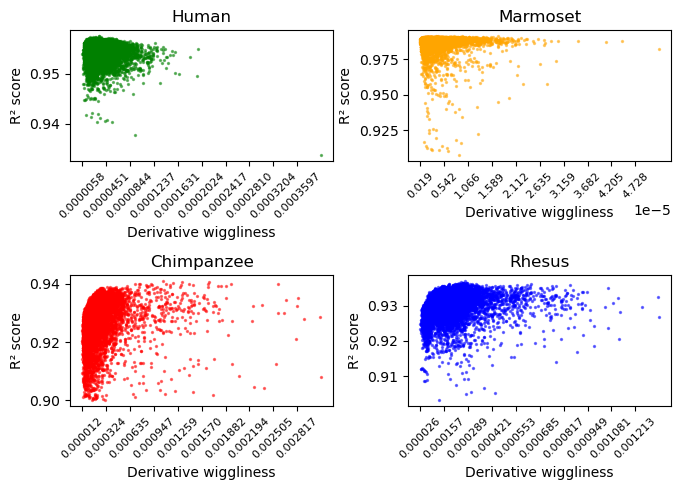

In [632]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(7,5))
i = 0
for row in ax:
    for col in row:
        species = species_list[i]
        sensitivity_df_species = sensitivity_df[sensitivity_df["Species"] == species]

        col.scatter(sensitivity_df_species["derivative_wiggliness"],
                    sensitivity_df_species["r2_score"],
                    color=species_color[species],
                    s=2, alpha=0.5)
        col.set_title(species)
        col.set_xlabel("Derivative wiggliness")
        
        x_min_value = np.min(sensitivity_df_species["derivative_wiggliness"])
        x_max_value = np.max(sensitivity_df_species["derivative_wiggliness"])

        col.set_xticks(np.arange(x_min_value,x_max_value,(x_max_value - x_min_value)/10))
        col.tick_params(axis='x', labelsize=8,rotation=45)
        col.set_ylabel("R² score")
        i += 1
plt.tight_layout()
plt.show()

## Filter

In [ ]:
#r2_species = {"Human": 0.95, "Chimpanzee":0.92, "Rhesus": 0.92, "Marmoset": 0.985}
#max_growth_wiggliness_species = {"Human": 1*10**(-1), "Chimpanzee":1*10**(-2), "Rhesus": 1*10**(-2), "Marmoset":1*10**(-4)}
max_derivative_wiggliness_species = {"Human": 1*10**(-4), "Chimpanzee": 1*10**(-4), "Rhesus": 1*10**(-4), "Marmoset": 1*10**(-6)}

sensitivity_df_filterd = pd.DataFrame()
for species in species_list:
    sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)
                                        #& (sensitivity_df.r2_score > r2_species[species])
                                        #& (sensitivity_df.wiggliness < max_growth_wiggliness_species[species])
                                        & (sensitivity_df.derivative_wiggliness < max_derivative_wiggliness_species[species])
                                        ]
    sensitivity_df_filterd = pd.concat([sensitivity_df_filterd,sensitivity_df_species])
    
derivatives_dataset_filtered, sensitivity_df_filterd = create_derivatives_dataset(sensitivity_df_filterd,x_each_species,species_list,gestation_periods_plot,gestation_periods_sd)
derivatives_dataset_filtered.head()


,Species,derivatives,derivatives_wiggliness,derivatives_max,derivatives_peak_at_birth,growth_curve_r2_score,growth_curve_wiggliness
0,Human,"[[3.064614918457664e-05, 0.0001225853041546543...","[2.227404646878772e-05, 2.135683822570055e-05,...","[2.4194334486632556, 2.3492183323747895, 2.680...","[[0.06434829108500505, 0.06608864961643122, 0....","[0.9559578868566582, 0.95564256202385, 0.95529...","[0.07380311658005818, 0.07082885638031204, 0.1..."
1,Marmoset,"[[-3.461231301571388e-12, -3.5487168759118504e...","[7.372686381672573e-07, 9.127438433565792e-07,...","[0.07450135434353378, 0.07858159977567802, 0.0...","[[0.016807876924726305, 0.019268520623952585, ...","[0.987459882056388, 0.9871081118293421, 0.9895...","[0.00019460412503076875, 0.0002180215589096474..."
2,Chimpanzee,"[[9.404629309983648e-06, 3.761861931650401e-05...","[3.7521668329939725e-05, 2.1829549923898916e-0...","[1.1478227360204727, 1.1026191926860491, 1.191...","[[0.19500279676998464, 0.19793996032802777, 0....","[0.9248656808902553, 0.9236051643444025, 0.928...","[0.03002335872228347, 0.023189620758404146, 0...."
3,Rhesus,"[[0.0023179056404032394, 0.002373807627403579,...","[5.3675591228956116e-05, 4.95356308955699e-05,...","[0.7734570127717522, 0.7663530654780821, 0.758...","[[0.5695318153447586, 0.5868433007572216, 0.60...","[0.9302963453978185, 0.9298925297368481, 0.929...","[0.01986676510861531, 0.018989025018162083, 0...."


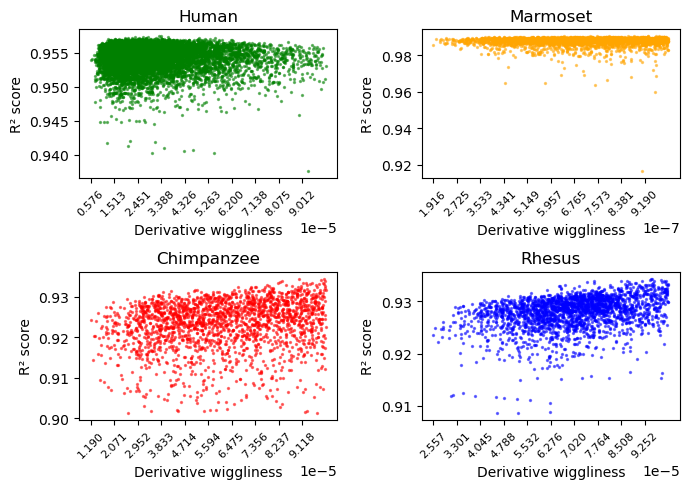

In [790]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(7,5))
i = 0
for row in ax:
    for col in row:
        species = species_list[i]
        sensitivity_df_species = sensitivity_df_filterd[sensitivity_df_filterd["Species"] == species]

        col.scatter(sensitivity_df_species["derivative_wiggliness"],
                    sensitivity_df_species["r2_score"],
                    color=species_color[species],
                    s=2, alpha=0.5)
        col.set_title(species)
        col.set_xlabel("Derivative wiggliness")
        
        x_min_value = np.min(sensitivity_df_species["derivative_wiggliness"])
        x_max_value = np.max(sensitivity_df_species["derivative_wiggliness"])

        col.set_xticks(np.arange(x_min_value,x_max_value,(x_max_value - x_min_value)/10))
        col.tick_params(axis='x', labelsize=8,rotation=45)
        col.set_ylabel("R² score")
        i += 1
plt.tight_layout()
plt.show()

Human
Marmoset
Chimpanzee
Rhesus


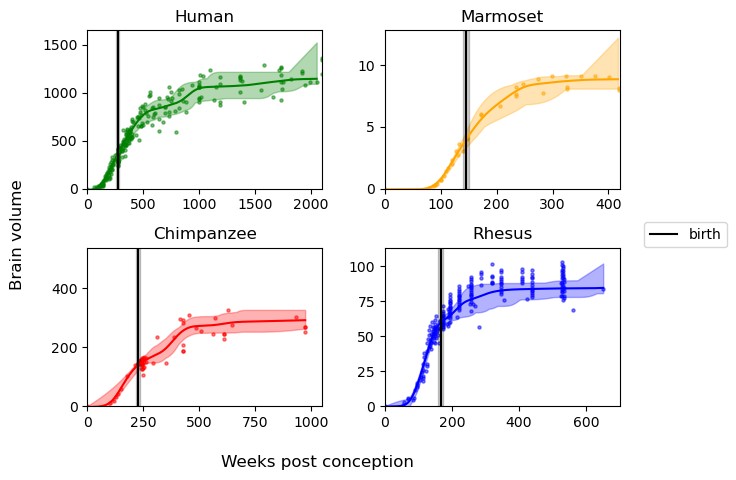

In [791]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        df_species = df[(df.Species == species)]
        sensitivity_df_species = sensitivity_df_filterd[(sensitivity_df_filterd.Species == species)]
        col.scatter(df_species[FIT_VARIABLE],df_species["total_cm3"],color = species_color[species], marker = 'o', s =5,alpha =0.5)
        col.set_title(species)
        
        all_curves = sensitivity_df_species["values"].tolist()
        average_curve = np.mean(np.array(all_curves), axis=0)
        min_curve = np.min(np.array(all_curves), axis=0)
        max_curve = np.max(np.array(all_curves), axis=0)


        col.plot(x_each_species[species], average_curve, '-', color = species_color[species],alpha = 1)
        col.fill_between(x_each_species[species], min_curve,max_curve, color=species_color[species], alpha=0.3)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')

        col.set_xlim(0,cut_period[species]*7)
        col.set_ylim(bottom=0)

        i += 1


fig.supxlabel('Weeks post conception') 
fig.supylabel('Brain volume')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

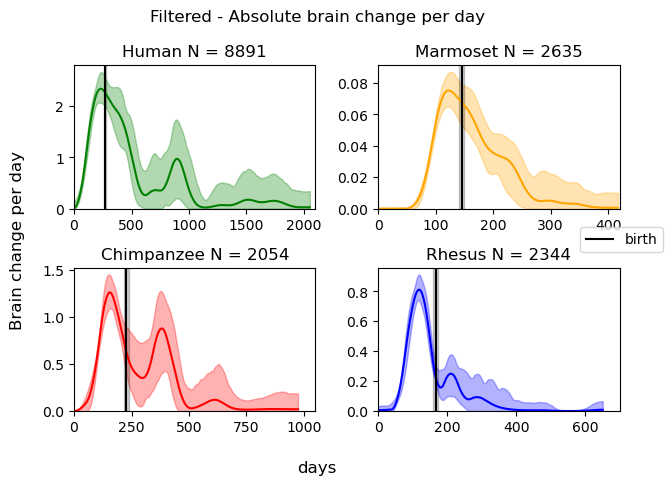

In [792]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species= species_list[i]
        derivatives_dataset_species = derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = np.mean(np.array(all_devs), axis=0)
        low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
        max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

        col.fill_between(x_each_species[species], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)
        col.plot(x_each_species[species], average_derivative, '-', color = species_color[species],alpha = 1)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species]*7)
        col.set_title(species + f" N = {len(all_devs)}")

        i += 1
        
fig.suptitle("Filtered - Absolute brain change per day")
fig.supxlabel('days') 
fig.supylabel('Brain change per day')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.tight_layout()
plt.show()

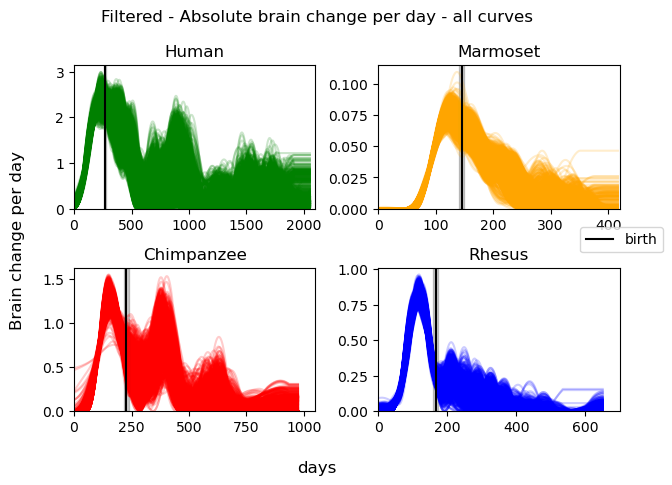

In [793]:
i = 0
derivative_data_species = {}
average_derivative = []
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species= species_list[i]
        derivatives_dataset_species = derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]
        all_devs = derivatives_dataset_species["derivatives"].values[0]

        for dev in all_devs:
            dev = np.array(dev)
            col.plot(x_each_species[species], dev, '-', color = species_color[species],alpha = 0.2)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species]*7)
        col.set_title(species)

        i += 1

fig.suptitle("Filtered - Absolute brain change per day - all curves")
fig.supxlabel('days') 
fig.supylabel('Brain change per day')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.tight_layout()
#fig.savefig("{0}/figs/S4.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

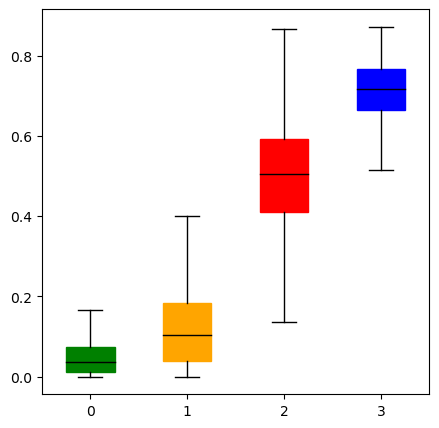

In [794]:
fig, ax = plt.subplots(figsize = (5,5))
for species in species_list:
    derivatives_dataset_species = derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]
    all_distances_from_the_peak = []
    for each_derivative in derivatives_dataset_species["derivatives_peak_at_birth"].values[0]:
        all_distances_from_the_peak.extend(each_derivative)

    #plot as boxplots, each species in a different position in the x axis:
    ax.boxplot(x = all_distances_from_the_peak, positions= [species_list.index(species)], widths=0.5, showfliers=False,patch_artist=True, boxprops=dict(facecolor=species_color[species], color=species_color[species]), medianprops=dict(color="black"),whiskerprops=dict(color="black"))


In [795]:
df_save = {"species":[],"x_dydx":[],"derivatives":[],"derivatives_max":[],"derivatives_peak_at_birth":[]}    

for species in species_list:

    df_save["species"].append(species)
    df_save["x_dydx"].append(x_each_species[species])
    df_save["derivatives"].append(derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]["derivatives"].item())
    df_save["derivatives_max"].append(derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]["derivatives_max"].item())
    df_save["derivatives_peak_at_birth"].append(derivatives_dataset_filtered[(derivatives_dataset_filtered.Species == species)]["derivatives_peak_at_birth"].item())


df_save = pd.DataFrame(df_save)
df_save.to_pickle("{0}/data/derivatives_absolute_values.pkl".format(PYTHON_PATH)) 
